In [2]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
from google.colab.patches import cv2_imshow
# Load the required libraries

# TASK-1




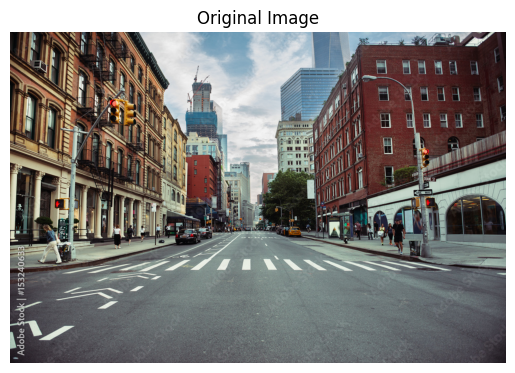

In [3]:
# Load my image
img=cv2.imread('road.jpg')
img=cv2.cvtColor(img,cv2.COLOR_BGR2RGB) # Need to to convert it into RGB as opencv by default read it as rgb image
plt.imshow(img) # cv2.imshow was not consistent in working with colab, also I feel more comfy using matplotlib
# Else could have used cv2_imshow
plt.title('Original Image')
plt.axis('off')
plt.show()

Grayscale Image


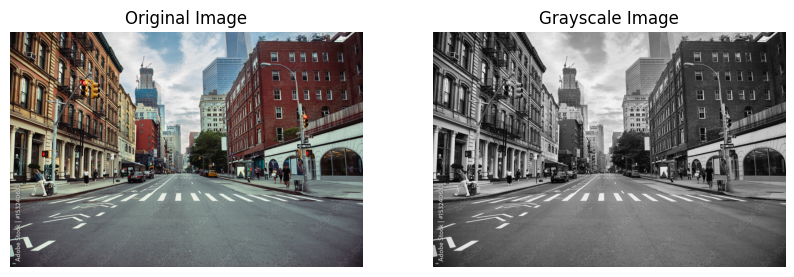

In [4]:
# Convert to Grayscale
img_gray=cv2.cvtColor(img,cv2.COLOR_RGB2GRAY)
plt.figure(figsize=(10,10))
plt.subplot(1,2,1)
plt.imshow(img)
plt.title('Original Image')
plt.axis('off')
plt.subplot(1,2,2)
plt.imshow(img_gray,cmap='gray')
plt.title('Grayscale Image')
plt.axis('off')
plt.show()

Basic Operations: Flipping, Rotating, Blurring,Cropping

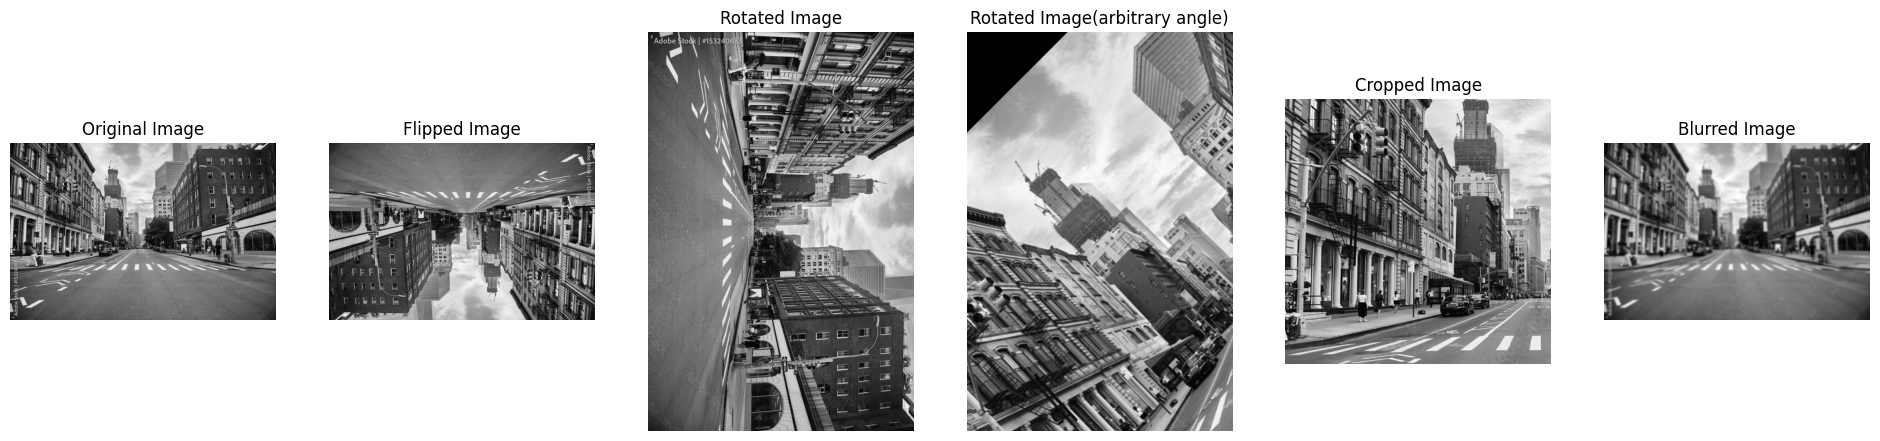

In [5]:
img_flipped=cv2.flip(img_gray,-1) # Both upright and lateral flipping

img_rotated=cv2.rotate(img_gray,cv2.ROTATE_90_CLOCKWISE) # Rotate by 90 degree clockwise

# Arbitrary Angle Rotation
angle=45
h,w=img_gray.shape
Rotated_Matrix=cv2.getRotationMatrix2D(( h//2, w//2),angle,1.0)
Rotated_Image=cv2.warpAffine(img_gray,Rotated_Matrix,(h//2,w//2))

img_blurred=cv2.GaussianBlur(img_gray,(15,15),0) # Apply Gaussian Blur and did it with 15 x 15 kernel to make blurring more prominent

# Image cropping
img_cropped=img_gray[100:500,100:500]

# Display outputs along with original image:

plt.figure(figsize=(24,6))

# Original Image
plt.subplot(1,6,1)
plt.imshow(img_gray,cmap='gray')
plt.title('Original Image')
plt.axis('off')

# Flipped Image
plt.subplot(1,6,2)
plt.imshow(img_flipped,cmap='gray')
plt.title('Flipped Image')
plt.axis('off')

# Rotated Image(Straight forward method)
plt.subplot(1,6,3)
plt.imshow(img_rotated,cmap='gray')
plt.title('Rotated Image')
plt.axis('off')

# Arbitrary Angle Rotation
plt.subplot(1,6,4)
plt.imshow(Rotated_Image,cmap='gray')
plt.title('Rotated Image(arbitrary angle)')
plt.axis('off')

# Cropped Image
plt.subplot(1,6,5)
plt.imshow(img_cropped,cmap='gray')
plt.title('Cropped Image')
plt.axis('off')

# Blurred Image
plt.subplot(1,6,6)
plt.imshow(img_blurred,cmap='gray')
plt.title('Blurred Image')
plt.axis('off')

plt.show()


Edge Detection


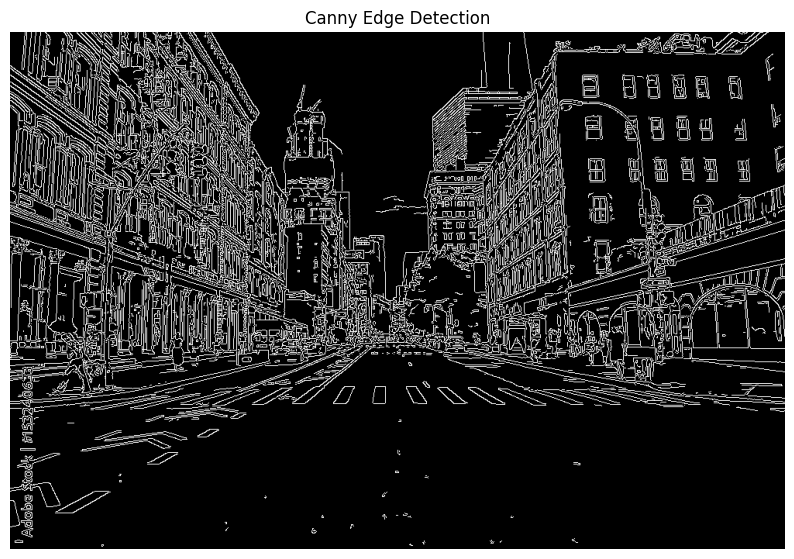

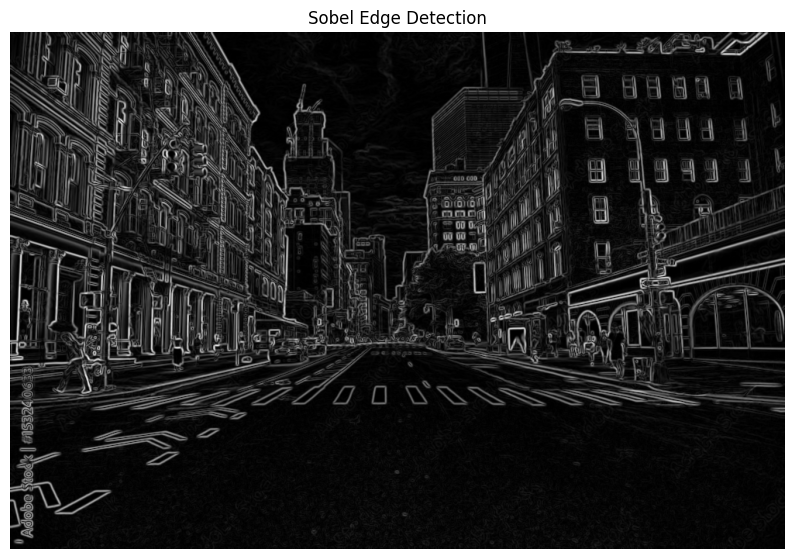

In [6]:
# Canny Edge Detection
img_edges=cv2.Canny(img_gray,100,200)
plt.figure(figsize=(10,10))
plt.imshow(img_edges,cmap='gray')
plt.title('Canny Edge Detection')
plt.axis('off')
plt.show()

# Sobel edge detection
Sobel_X=cv2.Sobel(img_gray,cv2.CV_64F,1,0,ksize=5)
Sobel_Y=cv2.Sobel(img_gray,cv2.CV_64F,0,1,ksize=5)
Sobel=cv2.magnitude(Sobel_X,Sobel_Y)
plt.figure(figsize=(10,10))
plt.imshow(Sobel,cmap='gray')
plt.title('Sobel Edge Detection')
plt.axis('off')
plt.show()

From the outputs, it is very clear how edge detection is very useful for lane detection and defining boundaries. As in the diagram, itself how clearly the patches of zebra crossing and lanes have been clearly demarcated. Also, note that we can clearly identify the road boundaries as well.

I have carried out edge detection using :- 'Canny-Edge Detection' and ' Sobel-Edge Detetction'. We can clearly see that ' Canny Detection' gives a  more clear view of edges and is more prominent in perceiving lanes and boudaries of road.

So, Canny detetction is way more accurate than Sobel.





# TASK-2


In [7]:
# Can't play the loaded video due to memory limit as it consumes a lot of memory


cap = cv2.VideoCapture("night_road.mp4")

if not cap.isOpened():
    print("Error: Could not open the video.")
    exit()

frame_count = 0
MAX_FRAMES = 20   # number of frames limited to 20 due to memory limit restrictions

while frame_count < MAX_FRAMES:
    ret, frame = cap.read()
    if not ret:
        break

    gray_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    edges_frame = cv2.Canny(gray_frame, 50, 150)

    print(f"Frame {frame_count}")
    cv2_imshow(frame)
    cv2_imshow(gray_frame)
    cv2_imshow(edges_frame)

    frame_count += 1

cap.release()


Output hidden; open in https://colab.research.google.com to view.

From output, we can clearly interpret how videos are sequences of images.
Also, we also know can conclude that how images at different time frames helps us to give a better idea of postion of the vehicle and lanes. Moreover, it helps to understand to estimate the proximity distance from other objects/vehicles or from the periphery of the road at different time frames ( to ultimately estimate the relative position between two cars at a time instant).

Further,we also note that the time taken to process the video is quite large, indicating that the whole process becomes computationally expenisve and
consumes too large resources. However, still it becomes important to carry out video processing for things like Lane Detection.
